In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pyeCAP
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
import pandas as pd
from tdt import read_block

In [3]:
#path = r'E:\NeuraWorx\TDT_data\20240308_NeuraWorx\NeuraWorx_Ind_Stim_ParamSeq-240308-092952\\'
#file = r'\JCW-240308-150011' #KAL high amplitude stims
#file = r'\CM-240308-094931' #CM V1 stims
#file = r'\CM-240308-103824' #CM V1 stims - long off time
#file = r'\JCW-240308-130125' #JCW V1 stims

path = r'E:\NeuraWorx\TDT_data\20240315_NeuraWorx\NeuraWorx_Ind_Stim_ParamSeq-240315-095625\\'
file = r'\KAL-240315-105510'
#file = r'\KAL-240315-140439' #Thresholding to repeat end of day
#file = r'\KAL-240315-144950' #Multi-stims at end of day

filePATH = path + file

In [4]:
raw_ecg = pyeCAP.Ephys(filePATH, stores='ECGG')
raw_ecg = raw_ecg.remove_ch(channels=['ECGG 3', 'ECGG 4'])
raw_TCD = pyeCAP.Ephys(filePATH, stores='TCDD')

time = raw_ecg.time()

stim = pyeCAP.Stim(filePATH)
stimDF = stim.parameters

TCD = pyeCAP.EMG(raw_TCD,stim)

In [5]:
stimDF

onset time (s)  offset time (s)  period (ms)  frequency (Hz)  \
0 0        35.269222        65.251939     9.994239      100.057645   
  1       162.269553       188.074351     0.286720     3487.723484   
  2       263.428588       289.233386     0.286720     3487.723484   
  3       354.690826       384.673543     9.994239      100.057645   
  4       485.137859       515.120575     9.994239      100.057645   
...              ...              ...          ...             ...   
  75     3687.840236      3713.645034     0.286720     3487.723484   
  76     3799.047250      3824.852048     0.286720     3487.723484   
  77     3891.537510      3921.520227     9.994239      100.057645   
  78     4000.184402      4030.167118     9.994239      100.057645   
  79     4093.372088      4119.176886     0.286720     3487.723484   

      pulse count  pulse amplitude (μA)  duration (ms)  pulse duration (ms)  \
0 0          3000               -7500.0   29982.716560                  0.2   
  1         90000               -7500.0   25804.798007                  0.2   
  2         90000               -7500.0   25804.798007                  0.2   
  3          3000               -7500.0   29982.716560                  0.2   
  4          3000               -7500.0   29982.716560                  0.2   
...           ...                   ...            ...                  ...   
  75        90000               -7500.0   25804.798007                  0.2   
  76        90000               -7500.0   25804.798007                  0.2   
  77         3000               -7500.0   29982.716560                  0.2   
  78         3000               -7500.0   29982.716560                  0.2   
  79        90000               -7500.0   25804.798007                  0.2   

      delay (ms)  channel voice store  
0 0          0.0        1     A  eS1p  
  1          0.0        1     A  eS1p  
  2          0.0        1     A  eS1p  
  3          0.0        1     A  eS1p  
  4          0.0        1     A  eS1p  
...          ...      ...   ...   ...  
  75         0.0        1     A  eS2p  
  76         0.0        1     A  eS2p  
  77         0.0        1     A  eS2p  
  78         0.0        1     A  eS2p  
  79         0.0        1     A  eS2p  

[80 rows x 12 columns]

In [133]:
params = stimDF.loc[(stimDF['pulse count'] == 90000) & (stimDF['store'] == 'eS1p')].index
params

MultiIndex([(0,  1),
            (0,  2),
            (0,  6),
            (0,  8),
            (0,  9),
            (0, 10),
            (0, 11),
            (0, 12),
            (0, 13),
            (0, 14),
            (0, 18),
            (0, 20),
            (0, 23),
            (0, 24),
            (0, 25),
            (0, 30),
            (0, 31),
            (0, 35),
            (0, 36),
            (0, 39)],
           )

In [6]:
TCD = raw_TCD.array[0,:]
TCD_vel = TCD * 100 #units = cm/s
time_s = np.arange(len(TCD)) / raw_TCD.sample_rate
time_m = time_s / 60

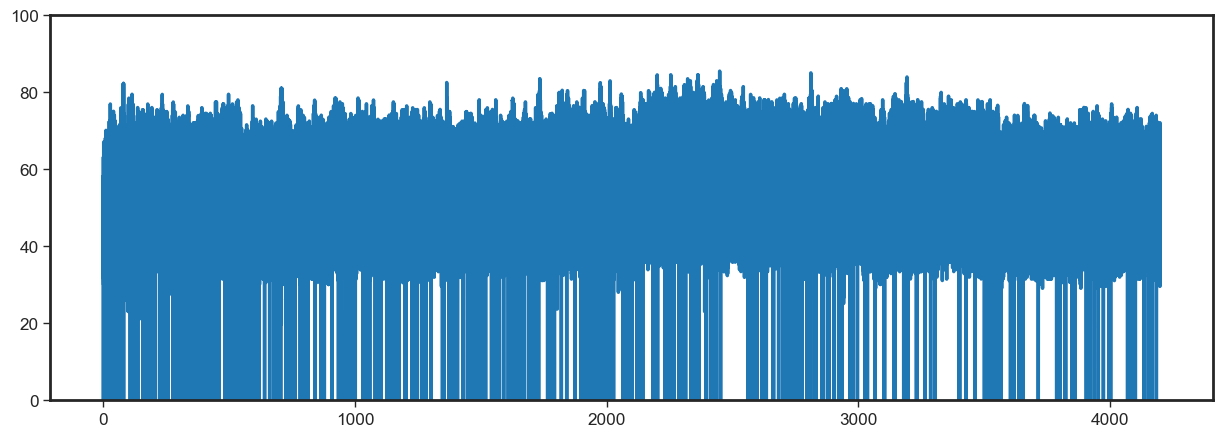

In [18]:
fig,ax = plt.subplots(figsize=(15,5))
ax.plot(time_s, TCD_vel)
ax.set_xlim(10,15)
ax.set_ylim(-0,100)
plt.show()

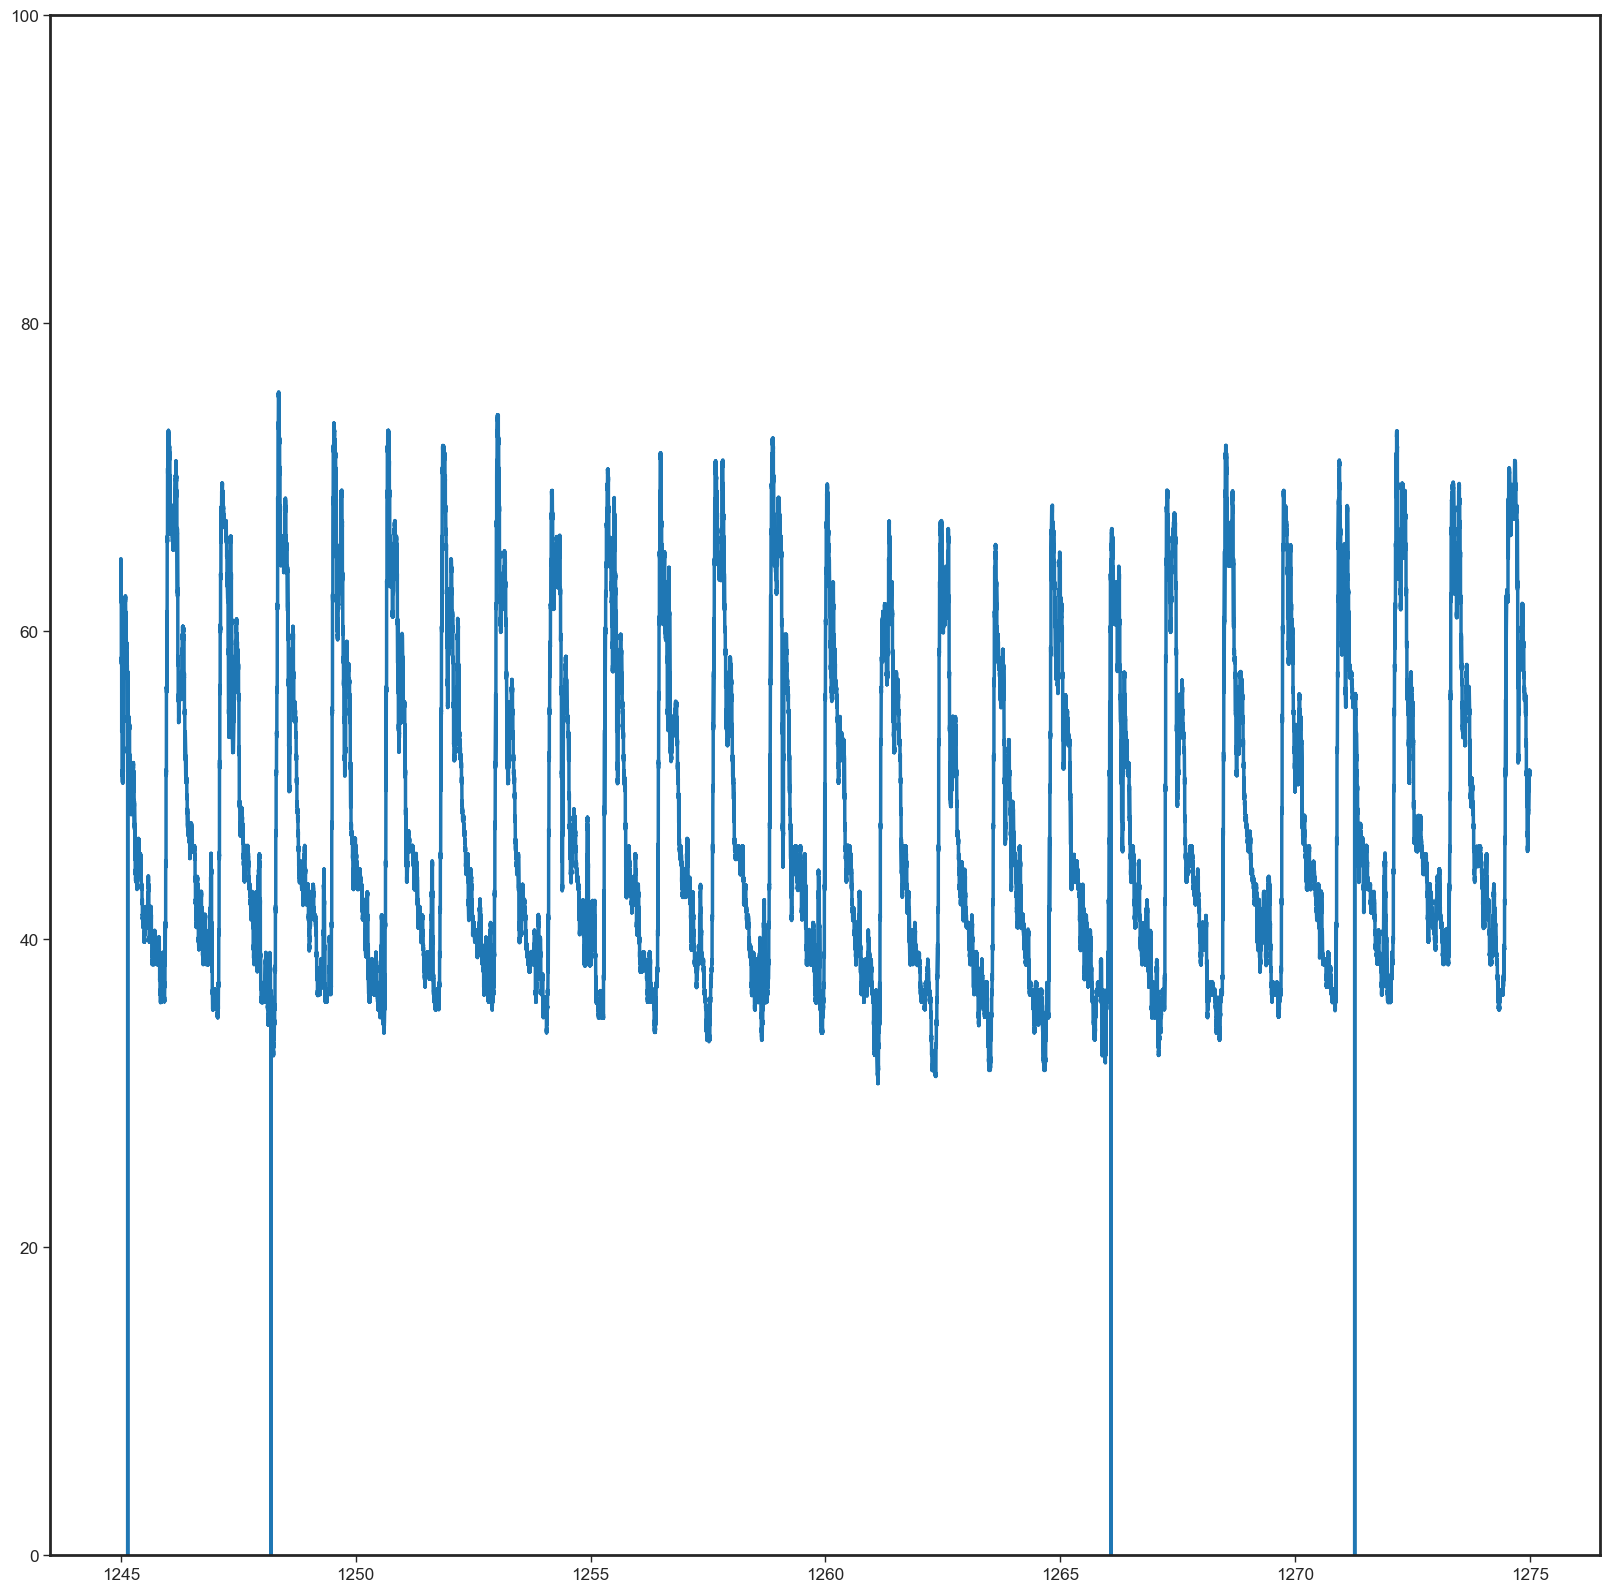

In [20]:
fig,ax = plt.subplots(figsize=(20,20))

stim_on = 1260
stim_off = 1260
    
plot_start_idx = int((stim_on - 15) * raw_TCD.sample_rate)
plot_stop_idx = int((stim_off + 15) * raw_TCD.sample_rate)
    
ax.plot(time_s[plot_start_idx:plot_stop_idx],TCD_vel[plot_start_idx:plot_stop_idx])
ax.set_ylim(0,100)

plt.show()

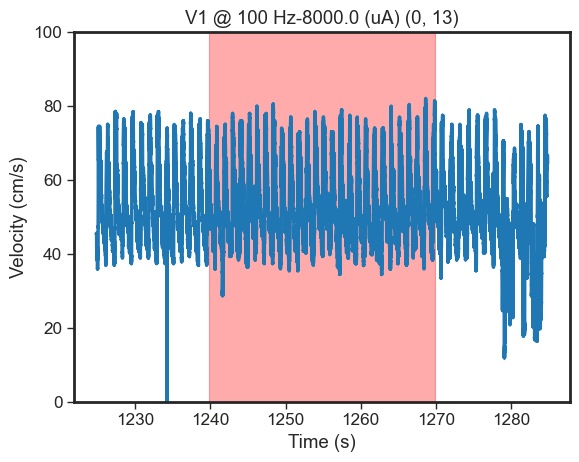

In [121]:
#for idx in stimDF.index[0:20]:
params = stimDF.loc[(stimDF['pulse count'] == 1200) & (stimDF['store'] == 'eS1p')].index
params

for idx in params:
    stim_idx_pairs.append([stimDF['onset time (s)'][idx], stimDF['offset time (s)'][idx]])
    
    stim_on = stimDF['onset time (s)'][idx]
    stim_off = stimDF['offset time (s)'][idx]
    
    plot_start_idx = int((stim_on - 15) * raw_TCD.sample_rate)
    plot_stop_idx = int((stim_off + 15) * raw_TCD.sample_rate)

    fig,ax = plt.subplots()
    ax.plot(time_s[plot_start_idx:plot_stop_idx],TCD_vel[plot_start_idx:plot_stop_idx])
    ax.set_ylim(0,100)
    ax.axvspan(stim_on,stim_off,alpha = 0.33, color='r')
    ax.set(title='V1 @ 100 Hz' + str(stimDF['pulse amplitude (μA)'][idx]) + ' (uA) ' + str(idx), xlabel='Time (s)', ylabel='Velocity (cm/s)')
plt.show()

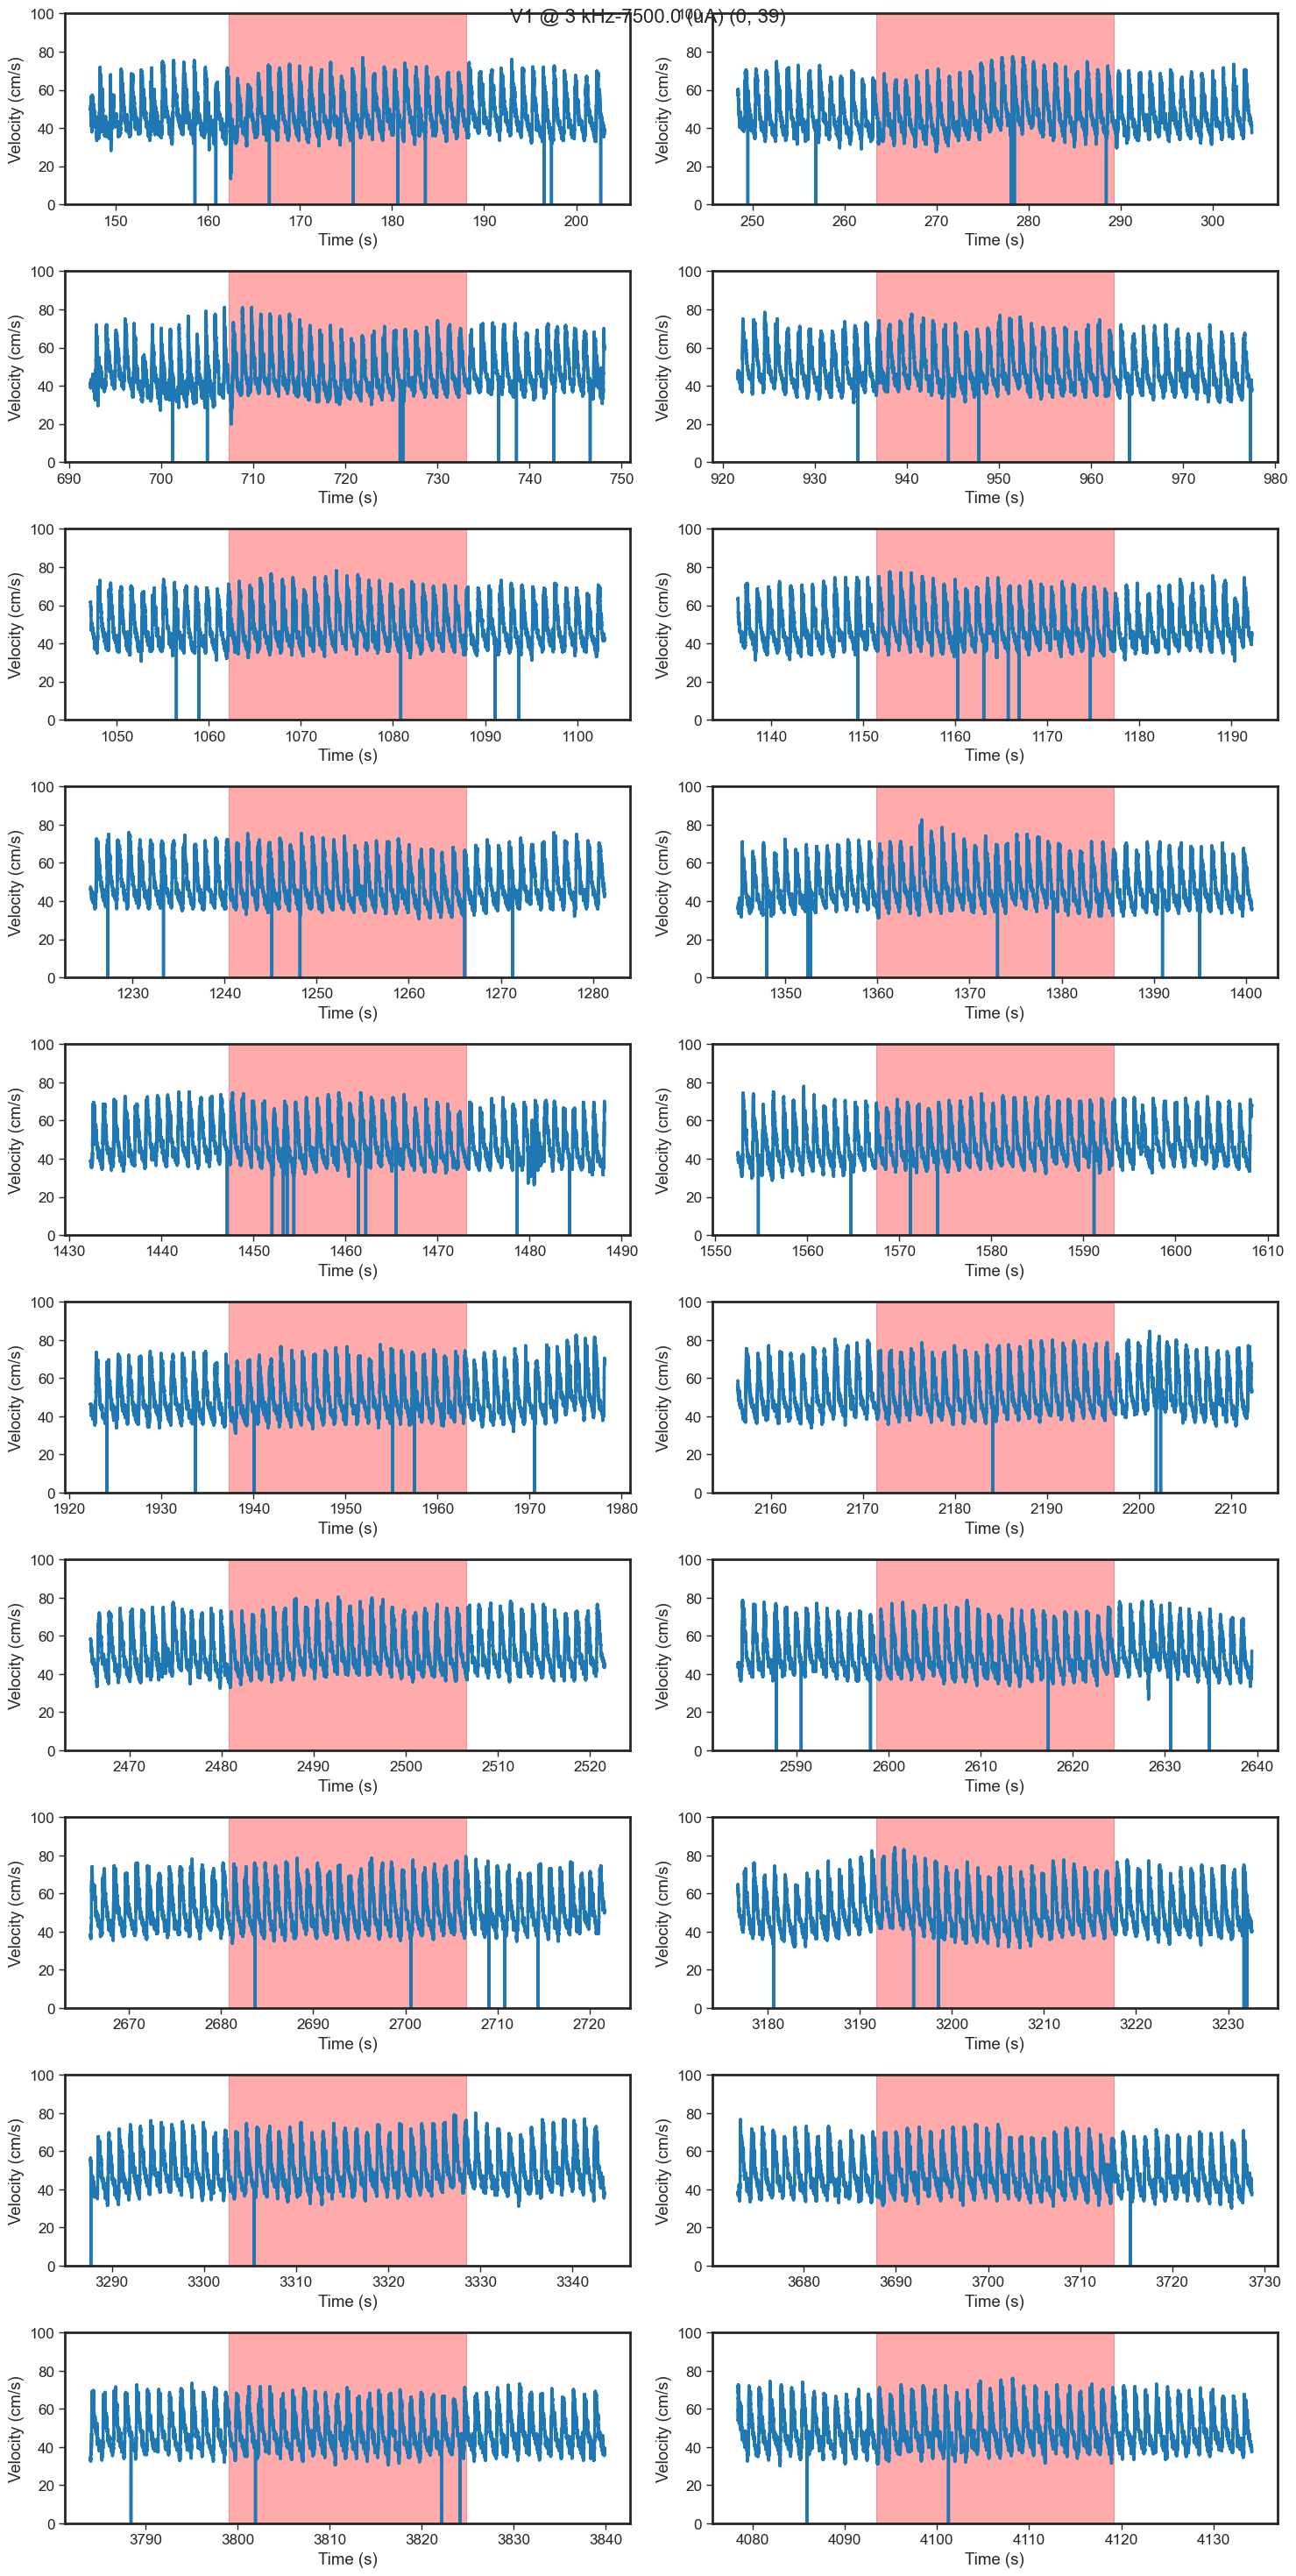

In [134]:
#for idx in stimDF.index[0:20]:
numcols = 2
numrows = int(len(params) / numcols)
fig,ax = plt.subplots(ncols=numcols,nrows=numrows, figsize=(15,30))
ax = ax.ravel()

for idx,param in enumerate(params):    
    stim_on = stimDF['onset time (s)'][param]
    stim_off = stimDF['offset time (s)'][param]
    
    plot_start_idx = int((stim_on - 15) * raw_TCD.sample_rate)
    plot_stop_idx = int((stim_off + 15) * raw_TCD.sample_rate)

    ax[idx].plot(time_s[plot_start_idx:plot_stop_idx],TCD_vel[plot_start_idx:plot_stop_idx])
    ax[idx].set_ylim(0,100)
    ax[idx].axvspan(stim_on,stim_off,alpha = 0.33, color='r')
    ax[idx].set(xlabel='Time (s)', ylabel='Velocity (cm/s)')
    fig.suptitle('V1 @ 3 kHz' + str(stimDF['pulse amplitude (μA)'][param]) + ' (uA) ' + str(param))
    fig.tight_layout()
plt.show()

In [ ]:
#ECG Filter Set-up
fs = raw_ecg.sample_rate
transition_width = 1
filter_cutoffs = [5,15]
numtaps = 3000
#numtaps = int(( 3.3 * fs) / (2 * transition_width)) * 2 + 1

filter_weights = signal.firwin(numtaps, filter_cutoffs, width=transition_width, window='Hamming', pass_zero = 'bandpass', fs=raw_ecg.sample_rate)

#Plot Frequency Response
#w,h = signal.freqz(filter_weights, worN = fft.next_fast_len(40000, real=True))
#plt.plot( (w / np.pi) * (fs/2), 20 * np.log10( np.abs(h)))
#plt.xlim((0,160))
#plt.show()

In [ ]:
raw_ecg.plot()

In [ ]:
ch1 = raw_ecg.array.compute()[0,:]  # Rectify signal
ch2 = raw_ecg.array.compute()[1,:] * -1
data_ref = ch1 - ch2

In [ ]:
raw_ecg.plot(channels='ECGG 2', x_lim=(0.55,0.65))

In [ ]:
fig,ax = plt.subplots(figsize=(25,5))
ax.plot(time_m, ch2)
ax.set(xlim=(0.55,0.65), ylim=(-0.001,0.001))
plt.show()

In [ ]:
ch1_filt = np.flip(signal.fftconvolve(np.flip(signal.fftconvolve(ch1, filter_weights,    
mode='same')), filter_weights, mode='same')) * 1e6
ch2_filt = np.flip(signal.fftconvolve(np.flip(signal.fftconvolve(ch2, filter_weights,    
mode='same')), filter_weights, mode='same'))* 1e6

In [ ]:
fig,ax = plt.subplots(figsize=(25,5))
ax.plot(time_m, ch2_filt)
ax.set(xlim=(0.55,0.65), ylim=(-1000,1000))
plt.show()

In [ ]:
ch1_sq = np.square(ch1_filt)
ch2_sq = np.square(ch2_filt)

In [ ]:
fig,ax = plt.subplots(figsize=(25,5))
ax.plot(time_m, ch2_sq)
#ax.set(xlim=(0.55,.65), ylim=(0,150e3))
plt.show()

In [ ]:
"""
Finds peaks based on parameters height and a minimum distance between peaks
"""
peaks = signal.find_peaks(ch2_sq, height = 30000, distance = raw_ecg.sample_rate * 0.5)

In [ ]:
#Calculate the number of samples between R-peaks
peak_to_peak = []
for i in range(len(peaks[0])):
    if i > 0:
        interval = peaks[0][i] - peaks[0][i-1]
        peak_to_peak.append(interval)
peak_intervals = np.array(peak_to_peak)

#Calculate time between consecutive R-waves to get time between heart beats
time_per_sample = 1 / fs
hr_intervals = peak_intervals * time_per_sample
hr_bpm = 60 / hr_intervals

#Create dataframe to pair the HR values with the index values from the raw data signal. Note the [1:] which drops the first peak value as no HR could be calculated based off of it
hrDF = pd.DataFrame(columns=['Index','Time (sec)', 'HR Intervals', 'HR (bpm)'])
hrDF['Index'] = peaks[0][1:]
hrDF['Time (sec)'] = hrDF['Index'] * time_per_sample
hrDF['HR Intervals'] = hr_intervals
hrDF['HR (bpm)'] = hr_bpm

In [ ]:
fig, ax = plt.subplots(figsize=(20,5))

ax.plot(hrDF['Time (sec)'], hrDF['HR (bpm)'])

for i in stimDF.index:
    onset = stimDF.loc[i]['onset time (s)']
    offset = stimDF.loc[i]['offset time (s)']
    ax.axvspan(onset,offset, alpha=0.25, color='red')

#ax.set_ylim((50,90))
#plt.title('KPC Mouthguard - Full')
plt.xlabel('Time (s)')
plt.ylabel('HR (bpm)')
plt.show()

In [ ]:
plt.close('all')
plt.clf()

time_window_start = 2000
time_window_end = 2180

plot_start_idx = int(time_window_start * raw_ecg.sample_rate)
plot_stop_idx = int(time_window_end * raw_ecg.sample_rate)

peaks_idx = np.squeeze(peaks[0])
peaks_to_plot = peaks_idx[ (peaks_idx >= plot_start_idx) * (peaks_idx <= plot_stop_idx)]
HR_plot = hrDF.loc[ (hrDF['Index'] >= plot_start_idx) & (hrDF['Index'] <= plot_stop_idx)]

fig, ax = plt.subplots(nrows = 2, ncols=1, figsize=(25,15))

"""
Upper plot of filtered data with calculated HR (bpm) overlaid
"""
ax[0].plot(time[plot_start_idx:plot_stop_idx], ch2_filt[plot_start_idx:plot_stop_idx])
ax[0].scatter(peaks_to_plot * time_per_sample, ch2_filt[peaks_to_plot],s=50, c='r', marker='x')  #the [0] is needed for peaks as it 
# returns a 
# tuple with the first element being the index values
#ax[0].set_ylim(-250,350)
ax2 = ax[0].twinx()
ax2.plot(HR_plot['Time (sec)'], HR_plot['HR (bpm)'], color='red')

"""
Lower plot shows the filtered_data_sq that peak indices were derived from. Red line indicates height threshold
"""
ax[1].plot(time[plot_start_idx:plot_stop_idx],ch2_sq[plot_start_idx:plot_stop_idx])
#ax[1].set_xlim((time_window_start, time_window_end))
ax[1].axhline(y=50000, color = 'r', linestyle='-')

plt.show()
plt.close('all')

In [ ]:
fig, ax = plt.subplots(figsize=(20,5))

ax.plot(hrDF['Time (sec)'], hrDF['HR (bpm)'])

for i in stimDF.index:
    onset = stimDF.loc[i]['onset time (s)']
    offset = stimDF.loc[i]['offset time (s)']
    ax.axvspan(onset,offset, alpha=0.25, color='red')

#ax.set_ylim((50,90))
#plt.title('KPC Mouthguard - Full')
plt.xlabel('Time (s)')
plt.ylabel('HR (bpm)')
plt.show()

In [ ]:
stim_idx_pairs = []

#for idx in stimDF.index[0:20]:
numcols = 2
numrows = int(len(params) / numcols)

for idx in params:   
    stim_on = stimDF['onset time (s)'][idx]
    stim_off = stimDF['offset time (s)'][idx]
    
    plot_start = stim_on - 30 
    plot_stop = stim_off + 30

    fig,ax = plt.subplots()
    ax.plot(hrDF['Time (sec)'], hrDF['HR (bpm)'], color='red')
    ax.set(xlim=(plot_start,plot_stop), ylim = (40,70))
    ax.axvspan(stim_on,stim_off,alpha = 0.33, color='r')
plt.show()